# Verifying the TomatoPlantfactoryDataset (Data in Brief, 2023)

**Paper:** Wu, Z.-W., Liu, M.-H., Sun, C.-X. & Wang, X.-F., *A dataset of tomato fruits images for object detection in the complex lighting environment of plant factories*, **Data in Brief** 48, 109291 (2023). [doi:10.1016/j.dib.2023.109291](https://doi.org/10.1016/j.dib.2023.109291) (open PMC copy [PMC10294037](https://pmc.ncbi.nlm.nih.gov/articles/PMC10294037/))

**Dataset:** [TomatoPlantfactoryDataset](https://data.mendeley.com/datasets/8h3s6jkyff/1), Mendeley Data DOI [10.17632/8h3s6jkyff.1](https://doi.org/10.17632/8h3s6jkyff.1) (version 1, the version cited by the paper), CC BY 4.0.

**Author quick-start code:** [veveup/Tomato-Plant-Factory-Dataset](https://github.com/veveup/Tomato-Plant-Factory-Dataset) at pinned commit `596c75e04ea08f8fec36c8104106cd92e1ebb132` (postdates the 2023 paper; it documents the same dataset).

## What this notebook does (exact scope)

This is a **dataset paper**: the contribution is the annotated image dataset itself, and no detection model or weights were released for it (the SM-YOLOv5 detector belongs to a companion paper). The minimal faithful reproduction is therefore to **verify the published dataset against the paper's claims**:

1. Download the official Mendeley v1 archive inside Colab and check its recorded SHA-256 and byte size.
2. Extract it and confirm the documented layout (`Images/`, `Annotations/`, `labels/`).
3. Preview real sample images and their **real ground-truth annotations** (Pascal VOC boxes overlaid on the original input).
4. Run the authors' `verify_dataset.py` **verbatim** from the pinned commit, then independently recount all annotations and compare with the published claims: **520 images, 9112 VOC objects (5996 green, 3116 red), YOLO labels with 8223 rows, the 889-object difference being `difficult`-marked green fruits.**
5. Cross-check VOC boxes against YOLO rows numerically, and build the authors' reproducible 0.8/0.1 train/val/test split (seed 42).

**Not done here:** detector training/evaluation — no paper-matched weights exist, and the quick-start YOLOv8 training postdates the paper.

> **AI-assisted note:** the glue cells in this notebook were AI-authored; `verify_dataset.py` and `prepare_yolo_split.py` are the authors' pinned code fetched and executed verbatim. The executed example and checks were validated in a fresh Colab run, but untested behavior beyond this scope is not guaranteed.
>
> **AI支援の説明:** 本ノートブックの接着セルはAIが作成しました。`verify_dataset.py` と `prepare_yolo_split.py` は著者らのピン留めされたコードをそのまま実行しています。検証済みの範囲外の動作は保証されません。

**Execution status:** executed end-to-end on a fresh Colab **CPU** runtime (validation record at the bottom).

*Japanese summary (概要):* 本ノートブックは2023年のデータセット論文(Data in Brief 48:109291)の「TomatoPlantfactoryDataset」(520枚・9112個体のgreen/redアノテーション、VOC XML+YOLO TXT)をColab上で検証します。Mendeley v1アーカイブ(約3.4 GB)をダウンロードし、SHA-256確認・展開・著者スクリプトの実行・アノテーション再計数・VOC⇔YOLO整合チェック・seed 42のデータ分割を行います。物体検出モデルの学習は行いません(重みが公開されていないため)。CPUランタイムで約15〜20分(ダウンロード速度に依存)。

## Runtime selection and how to run

**Select Runtime → Change runtime type → CPU** (the default free runtime). No GPU is needed: this notebook only downloads/unpacks an archive, parses XML/TXT annotations, and renders images with Pillow/matplotlib.

**Run all** (Runtime → Run all). Expected duration is dominated by the **3.4 GB single-file archive download** (typically a few minutes on Colab; variable by network). Disk need is about 10 GB in `/content` (archive + extraction + split links).

**Limitations:** the archive is a single monolithic zip on Mendeley Data, so the full download is required to verify the paper's dataset-level counts; per-file ZIP CRCs are verified by `zipfile` during extraction and the whole-file SHA-256 is checked against the Mendeley-recorded value. Free-tier Colab sessions may be slower or preempted.

*Japanese:* GPUは不要です(CPUのみで動作)。実行時間の大半は約3.4 GBの単一zipのダウンロードです。ディスクは約10 GB使用します。

In [ ]:
import platform, shutil, sys
from pathlib import Path

import matplotlib
import PIL
import requests

print("Python:", platform.python_version())
print("Pillow:", PIL.__version__)
print("matplotlib:", matplotlib.__version__)
print("requests:", requests.__version__)
total, used, free = shutil.disk_usage("/content")
print(f"/content disk: total {total/1e9:.0f} GB, free {free/1e9:.0f} GB")
assert free > 12e9, "need > 12 GB free in /content for archive + extraction"
print("Runtime check OK (CPU is sufficient for this notebook)")

Python: 3.13.16
Pillow: 11.3.0
matplotlib: 3.10.0
requests: 2.32.4
/content disk: total 242 GB, free 213 GB
Runtime check OK (CPU is sufficient for this notebook)


### What this cell does / このセルの内容

Checks the interpreter and required libraries (all Colab-preinstalled: Pillow, matplotlib, requests) and verifies enough free disk for the 3.4 GB archive plus extraction. Nothing is downloaded yet.

*日本語:* Python・Pillow・matplotlib・requestsのバージョン確認と、アーカイブ+展開用に12 GB以上の空きディスクを確認します。まだダウンロードは行いません。

## Pinned provenance

| Artifact | Identity |
| --- | --- |
| Dataset archive | Mendeley Data record `10.17632/8h3s6jkyff.1` (version 1, publish date 2023-04-24, matching the paper's citation), single file `TomatoPlantfactoryDataset.zip`, size **3,402,876,899 bytes**, SHA-256 `e6bcaf1dfd6be32f62eadcfbfa99692e9feca6171cfcbfb5e54f728229905faf` (values from the Mendeley public record API; the bytes themselves are fetched only here, inside Colab). Mendeley versions 1–3 all record this identical size and SHA-256, so the archive content is unambiguous across versions. |
| Author code | `veveup/Tomato-Plant-Factory-Dataset` @ commit `596c75e04ea08f8fec36c8104106cd92e1ebb132`; `verify_dataset.py` (4729 bytes) and `prepare_yolo_split.py` (4728 bytes) fetched from pinned raw URLs and size-checked |

The download URL below is the content URL returned by the Mendeley v1 record's public file API (`https://data.mendeley.com/public-api/datasets/8h3s6jkyff/files?version=1&folder_id=root`) — a documented public route, no authentication required.

**Access note (verified 2026-10-08):** from Colab, plain `python-requests` receives a Cloudflare challenge (`Cf-Mitigated: challenge`, HTTP 403 HTML) on `data.mendeley.com`. The official URL therefore is resolved with `curl` (which reaches the HTTP 302) to its Amazon S3 backing store, and the bytes are then streamed with `requests`; a direct `curl -L` download is the fallback. The SHA-256 check below is the authority: the downloaded bytes must equal the Mendeley-recorded checksum regardless of route.

*Japanese:* ダウンロード元はMendeley Dataの公式記録(v1)で、サイズとSHA-256は記録APIの値と照合します。ColabからはCloudflareのボット判定があるため、公式URLのリダイレクト先(S3)をcurlで解決してから取得します。最終的な正否はSHA-256照合で決めます。

In [ ]:
import os
import subprocess
import time

import requests

DOWNLOAD_URL = (
    "https://data.mendeley.com/public-files/datasets/8h3s6jkyff/"
    "files/beabf9c1-06dd-44e7-848f-a4352035e34c/file_downloaded"
)  # content URL of the v1 record file TomatoPlantfactoryDataset.zip
ARCHIVE_PATH = "/content/TomatoPlantfactoryDataset.zip"
EXPECTED_SIZE = 3_402_876_899  # bytes, recorded by Mendeley for version 1

def resolve_redirect(url: str) -> str:
    proc = subprocess.run(
        ["curl", "-sS", "-D", "-", "-o", os.devnull, "--max-time", "60", url],
        capture_output=True, text=True, timeout=90,
    )
    for line in proc.stdout.splitlines():
        if line.lower().startswith("location:"):
            return line.split(":", 1)[1].strip()
    raise RuntimeError(f"no Location header from official URL: {proc.stdout[:200]} {proc.stderr[:200]}")

def download_streamed(url: str, dest: str, tries: int = 3) -> None:
    last_error = None
    for attempt in range(1, tries + 1):
        try:
            started = time.time()
            with requests.get(url, stream=True, timeout=(15, 300)) as response:
                response.raise_for_status()
                print(f"attempt {attempt}: HTTP {response.status_code}, "
                      f"content-length {response.headers.get('Content-Length')}")
                received = 0
                next_report = 500 << 20
                with open(dest, "wb") as fh:
                    for chunk in response.iter_content(chunk_size=8 << 20):
                        fh.write(chunk)
                        received += len(chunk)
                        if received >= next_report:
                            rate = received / max(time.time() - started, 1e-9) / 1e6
                            print(f"  {received/1e9:.2f} GB ({rate:.0f} MB/s)", flush=True)
                            next_report += 500 << 20
            if os.path.getsize(dest) == EXPECTED_SIZE:
                print(f"downloaded {os.path.getsize(dest)} bytes in {time.time() - started:.0f} s")
                return
            last_error = f"size mismatch: {os.path.getsize(dest)} != {EXPECTED_SIZE}"
            print(last_error)
        except Exception as exc:  # bounded retries, then fail loudly
            last_error = repr(exc)
            print(f"attempt {attempt} failed: {last_error}")
    raise RuntimeError(f"streamed download failed after {tries} attempts: {last_error}")

backing_url = resolve_redirect(DOWNLOAD_URL)
print("resolved backing URL:", backing_url.split("?")[0])
try:
    download_streamed(backing_url, ARCHIVE_PATH)
except RuntimeError:
    print("streamed download failed; falling back to curl -L on the official URL")
    subprocess.run(
        ["curl", "-sSL", "--max-time", "1800", "-o", ARCHIVE_PATH, DOWNLOAD_URL],
        check=True, timeout=2100,
    )
    assert os.path.getsize(ARCHIVE_PATH) == EXPECTED_SIZE, "curl fallback size mismatch"
    print(f"downloaded via curl: {os.path.getsize(ARCHIVE_PATH)} bytes")

resolved backing URL: https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/e3368c2e-8990-4cfc-8933-1d4e3d2776d5


attempt 1: HTTP 200, content-length 3402876899


  0.53 GB (30 MB/s)


  1.05 GB (32 MB/s)


  1.58 GB (32 MB/s)


  2.10 GB (32 MB/s)


  2.63 GB (33 MB/s)


  3.15 GB (33 MB/s)


downloaded 3402876899 bytes in 104 s


### What this cell does / このセルの内容

Downloads the pinned Mendeley v1 archive with streamed progress and at most three bounded attempts, asserting the recorded byte size. This is the notebook's dominant time cost.

*日本語:* Mendeley v1の公式アーカイブをストリーミングでダウンロードし(最大3回)、記録されたバイト数と一致することを確認します。この処理が全体の時間の大半を占めます。

In [ ]:
import hashlib

def sha256_of(path: str) -> str:
    digest = hashlib.sha256()
    with open(path, "rb") as fh:
        for block in iter(lambda: fh.read(8 << 20), b""):
            digest.update(block)
    return digest.hexdigest()

EXPECTED_SHA256 = "e6bcaf1dfd6be32f62eadcfbfa99692e9feca6171cfcbfb5e54f728229905faf"
actual_sha256 = sha256_of(ARCHIVE_PATH)
print("sha256:", actual_sha256)
assert actual_sha256 == EXPECTED_SHA256, "archive does not match the Mendeley-recorded checksum"
print("checksum OK: matches the Mendeley v1 record")

sha256: e6bcaf1dfd6be32f62eadcfbfa99692e9feca6171cfcbfb5e54f728229905faf
checksum OK: matches the Mendeley v1 record


### What this cell does / このセルの内容

Computes SHA-256 over the downloaded archive and compares it with the value recorded by Mendeley for version 1. A mismatch aborts the notebook.

*日本語:* ダウンロードしたアーカイブのSHA-256を計算し、Mendeley記録値と照合します。一致しない場合は中断します。

In [ ]:
import zipfile
from collections import Counter
from pathlib import Path

EXTRACT_ROOT = Path("/content")
with zipfile.ZipFile(ARCHIVE_PATH) as zf:
    members = zf.namelist()
    unsafe = [n for n in members if n.startswith("/") or ".." in Path(n).parts]
    assert not unsafe, f"unsafe archive members: {unsafe[:5]}"
    zf.extractall(EXTRACT_ROOT)  # per-member CRC32 is verified by zipfile on extraction
print(f"extracted {len(members)} members (zip CRC32 checked per member)")

def find_dataset_root(base: Path) -> Path:
    candidates = [base] + sorted(p for p in base.iterdir() if p.is_dir())
    for candidate in candidates:
        if all((candidate / d).is_dir() for d in ("Images", "Annotations", "labels")):
            return candidate
    raise RuntimeError("no directory with Images/, Annotations/ and labels/ found")

DATASET_ROOT = find_dataset_root(EXTRACT_ROOT)
print("dataset root:", DATASET_ROOT)
for sub in ("Images", "Annotations", "labels"):
    entries = sorted((DATASET_ROOT / sub).iterdir())
    extensions = Counter(entry.suffix for entry in entries if entry.is_file())
    print(f"  {sub}: {len(entries)} entries, extensions {dict(extensions)}")

extracted 1563 members (zip CRC32 checked per member)
dataset root: /content
  Images: 520 entries, extensions {'.JPG': 520}
  Annotations: 520 entries, extensions {'.xml': 520}
  labels: 520 entries, extensions {'.txt': 520}


### What this cell does / このセルの内容

Safely extracts the archive (rejecting absolute/`..` member names; `zipfile` verifies each member's CRC32 while extracting) and locates the dataset root, printing the documented `Images/`, `Annotations/`, `labels/` layout with per-directory file counts.

*日本語:* アーカイブを安全に展開し(不正なメンバー名は拒否、展開時にCRC32を検証)、論文記載の`Images/`・`Annotations/`・`labels/`構成と各ディレクトリのファイル数を表示します。

## Input preview — real samples with their real annotations

The three preview images are chosen **deterministically** (first, middle and last of the alphabetically sorted `Images/` directory), not for appearance. They are shown downscaled; original resolutions are printed in the titles (the paper reports Canon 80D 6000x4000 and iPhone 11 4032x3024 captures).

*Japanese:* プレビューにはソート順の先頭・中央・末尾の3枚を決定論的に使用します(見た目で選んでいません)。タイトルに元の解像度を表示します。

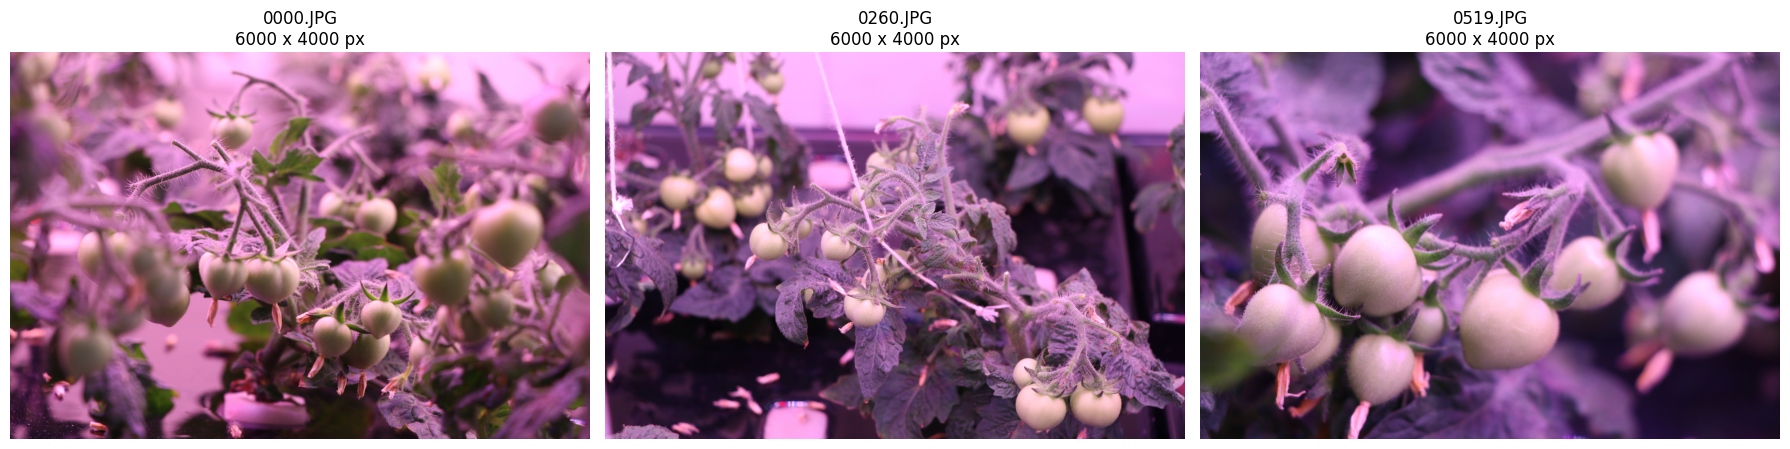

deterministic samples: ['0000.JPG', '0260.JPG', '0519.JPG']


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}
image_paths = sorted(
    p for p in (DATASET_ROOT / "Images").iterdir() if p.suffix in IMAGE_EXTENSIONS
)
sample_paths = [image_paths[0], image_paths[len(image_paths) // 2], image_paths[-1]]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, path in zip(axes, sample_paths):
    with Image.open(path) as im:
        width, height = im.size
        im.thumbnail((1400, 1400))
        ax.imshow(im)
        ax.set_title(f"{path.name}\n{width} x {height} px")
        ax.axis("off")
plt.tight_layout()
plt.show()
print("deterministic samples:", [p.name for p in sample_paths])

### What this cell does / このセルの内容

Lists the image directory, picks the deterministic samples, and renders them (downscaled) with their original resolutions. This is the human-readable input preview required before any analysis.

*日本語:* 画像ディレクトリから決定論的な3枚を選び、元解像度を表示しながら縮小プレビューします。

### Ground-truth overlay (input + reference annotation)

The overlay below draws the **Pascal VOC ground-truth boxes from the dataset's own `Annotations/` XML** — these are reference annotations, not model predictions. Green fruits are outlined green, red fruits red; `difficult`-marked objects (excluded from the YOLO labels) are dashed. This image is the representative saved output for this reproduction.

*Japanese:* 次のセルは、データセット自身のVOC XMLに含まれる正解バウンディングボックスを入力画像に重畳します(緑=green、赤=red、破線=difficult)。これはモデル予測ではなく参照アノテーションです。

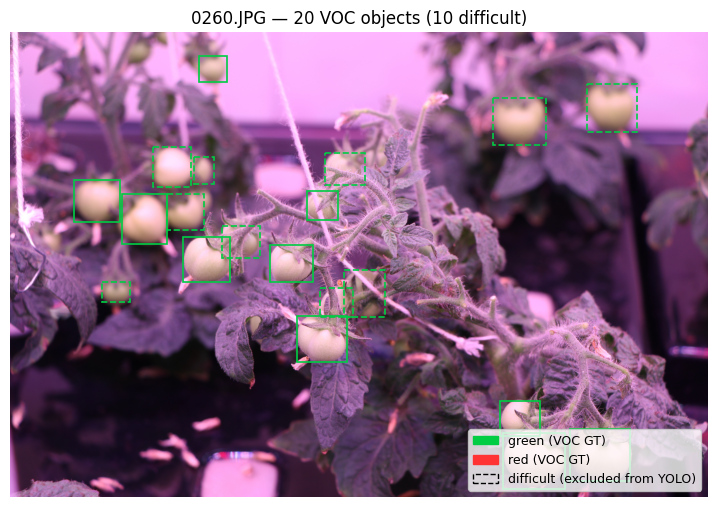

overlay: 0260.JPG, 20 objects, 10 difficult


In [ ]:
from xml.etree import ElementTree

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from PIL import Image

def parse_voc(xml_path):
    root = ElementTree.parse(xml_path).getroot()
    size = root.find("size")
    objects = []
    for obj in root.findall("object"):
        box = obj.find("bndbox")
        objects.append({
            "name": (obj.findtext("name") or "").strip(),
            "difficult": (obj.findtext("difficult") or "0").strip() == "1",
            "xmin": float(box.findtext("xmin")), "ymin": float(box.findtext("ymin")),
            "xmax": float(box.findtext("xmax")), "ymax": float(box.findtext("ymax")),
        })
    return int(size.findtext("width")), int(size.findtext("height")), objects

overlay_path = sample_paths[1]
xml_path = DATASET_ROOT / "Annotations" / f"{overlay_path.stem}.xml"
voc_w, voc_h, objects = parse_voc(xml_path)
with Image.open(overlay_path) as im:
    assert (voc_w, voc_h) == im.size, "VOC size does not match the image"
    fig, ax = plt.subplots(figsize=(9, 9))
    ax.imshow(im)
    colors = {"green": "#00cc44", "red": "#ff3333"}
    for obj in objects:
        style = "--" if obj["difficult"] else "-"
        ax.add_patch(mpatches.Rectangle(
            (obj["xmin"], obj["ymin"]), obj["xmax"] - obj["xmin"], obj["ymax"] - obj["ymin"],
            fill=False, edgecolor=colors[obj["name"]], lw=1.2, ls=style))
    legend_handles = [
        mpatches.Patch(color="#00cc44", label="green (VOC GT)"),
        mpatches.Patch(color="#ff3333", label="red (VOC GT)"),
        mpatches.Patch(edgecolor="black", fill=False, ls="--", label="difficult (excluded from YOLO)"),
    ]
    n_difficult = sum(o["difficult"] for o in objects)
    ax.legend(handles=legend_handles, loc="lower right", fontsize=9)
    ax.set_title(f"{overlay_path.name} — {len(objects)} VOC objects ({n_difficult} difficult)")
    ax.axis("off")
    Path("/content/outputs").mkdir(exist_ok=True)
    fig.savefig("/content/outputs/gt_overlay.png", dpi=110, bbox_inches="tight")
    plt.show()
print(f"overlay: {overlay_path.name}, {len(objects)} objects, {n_difficult} difficult")

### What this cell does / このセルの内容

Parses the middle sample's VOC XML, asserts the recorded image size matches the file, and draws all ground-truth boxes on the original image, saving `gt_overlay.png` under `/content/outputs` and rendering it here.

*日本語:* 中央のサンプルのVOC XMLを解析し、画像サイズの一致を確認した上で、全ての正解ボックスを元画像に重畳表示・保存します。

## Verification 1 — the authors' `verify_dataset.py`, run verbatim

The script below is fetched from the pinned commit and executed unchanged with the extracted dataset root. Expected per the paper and the repository documentation: **520 images, 520 VOC XMLs, 520 YOLO label files; VOC totals 9112 (5996 green + 3116 red); YOLO 8223 rows; the 889 difference is `difficult`-marked green fruits.**

*Japanese:* 著者の`verify_dataset.py`をピン留めコミットから取得し、そのまま実行します。期待値は論文・README記載の数値です。

In [ ]:
import sys
import urllib.request

AUTHOR_COMMIT = "596c75e04ea08f8fec36c8104106cd92e1ebb132"
RAW_BASE = f"https://raw.githubusercontent.com/veveup/Tomato-Plant-Factory-Dataset/{AUTHOR_COMMIT}"

urllib.request.urlretrieve(f"{RAW_BASE}/verify_dataset.py", "/content/verify_dataset.py")
assert Path("/content/verify_dataset.py").stat().st_size == 4729, "verify_dataset.py size mismatch"
print("fetched author verify_dataset.py from pinned commit", AUTHOR_COMMIT)

result = subprocess.run(
    [sys.executable, "/content/verify_dataset.py", "--root", str(DATASET_ROOT)],
    capture_output=True, text=True, timeout=600,
)
print(result.stdout)
assert result.returncode == 0, "author verify_dataset.py FAILED (see output above)"


fetched author verify_dataset.py from pinned commit 596c75e04ea08f8fec36c8104106cd92e1ebb132


Dataset root: /content
Images: 520
Pascal VOC XML files: 520
YOLO label files: 520

Pascal VOC object counts:
  green: 5996 (889 marked difficult)
  red: 3116 (0 marked difficult)
  total: 9112

YOLO object counts:
  green: 5107
  red: 3116
  total: 8223

OK: image, XML and YOLO file stems are aligned.



### What this cell does / このセルの内容

Downloads `verify_dataset.py` from the pinned author commit (size-checked against the repository tree), then runs it on the extracted dataset. Its printed counts and stem-alignment check must exit 0.

*日本語:* 著者の検証スクリプトをダウンロード(サイズ照合)し、展開済みデータセットに対して実行します。終了コード0(全ファイル整合)を確認します。

## Verification 2 — independent recount against the published claims

An independent pass over **all** XML/TXT files (not relying on the authors' script) builds a small verification table: per-class VOC object counts, `difficult` counts, YOLO row counts, and per-file agreement between VOC non-difficult objects and YOLO rows. Any mismatch with the published numbers aborts the notebook.

*Japanese:* 全てのXML/TXTを独自に再計数し、論文記載値(520画像・9112個体・green 5996・red 3116・YOLO 8223行・difficult 889)と照合します。不一致なら中断します。

In [ ]:
import pandas as pd

CLASS_NAMES = {0: "green", 1: "red"}
voc_counts, voc_difficult, yolo_counts = Counter(), Counter(), Counter()
row_mismatch_files = []

xml_paths = sorted((DATASET_ROOT / "Annotations").glob("*.xml"))
for xml_path in xml_paths:
    _, _, objects = parse_voc(xml_path)
    non_difficult = [o for o in objects if not o["difficult"]]
    lines = (DATASET_ROOT / "labels" / f"{xml_path.stem}.txt").read_text().splitlines()
    rows = [line.split() for line in lines if line.strip()]
    if len(rows) != len(non_difficult):
        row_mismatch_files.append(xml_path.name)
    for obj in objects:
        voc_counts[obj["name"]] += 1
        if obj["difficult"]:
            voc_difficult[obj["name"]] += 1
    for row in rows:
        yolo_counts[CLASS_NAMES[int(row[0])]] += 1

total_voc = sum(voc_counts.values())
total_voc_difficult = sum(voc_difficult.values())
total_yolo = sum(yolo_counts.values())
expected = {
    "images": len(image_paths),
    "voc xml files": len(xml_paths),
    "voc objects (total)": total_voc,
    "voc green": voc_counts["green"],
    "voc red": voc_counts["red"],
    "voc difficult (total)": total_voc_difficult,
    "yolo rows (total)": total_yolo,
}
paper_claims = {
    "images": 520, "voc xml files": 520, "voc objects (total)": 9112,
    "voc green": 5996, "voc red": 3116, "voc difficult (total)": 889,
    "yolo rows (total)": 8223,
}
checks = pd.DataFrame({
    "metric": list(expected.keys()),
    "measured": [expected[k] for k in expected],
    "paper claim": [paper_claims[k] for k in expected],
})
checks["match"] = checks["measured"] == checks["paper claim"]
display(checks)
assert checks["match"].all(), f"dataset does not match published claims: {checks.loc[~checks['match'], 'metric'].tolist()}"
assert not row_mismatch_files, f"{len(row_mismatch_files)} files where YOLO rows != VOC non-difficult objects"
print("all published counts reproduced; YOLO rows == VOC non-difficult objects in every file")

,metric,measured,paper claim,match
0,images,520,520,True
1,voc xml files,520,520,True
2,voc objects (total),9112,9112,True
3,voc green,5996,5996,True
4,voc red,3116,3116,True
5,voc difficult (total),889,889,True
6,yolo rows (total),8223,8223,True


all published counts reproduced; YOLO rows == VOC non-difficult objects in every file


### What this cell does / このセルの内容

Recounts every annotation independently and compares against the paper's published numbers in a table; raises if any claim fails or if any file's YOLO row count deviates from its VOC non-difficult object count.

*日本語:* 全アノテーションを再計数し、論文の公表値との照合表を作成します。食い違いや、YOLO行数≠VOC非difficult数のファイルがあれば中断します。

### Per-class instance counts (additional visualization)

The bar chart below is **created for this notebook** from the recount above — it is not a figure from the paper. It makes the green/red and difficult/non-difficult composition easy to read.

*Japanese:* 次の棒グラフは本ノートブック用に作成した追加可視化であり(論文の図ではありません)、クラス別・difficult別の集計を示します。

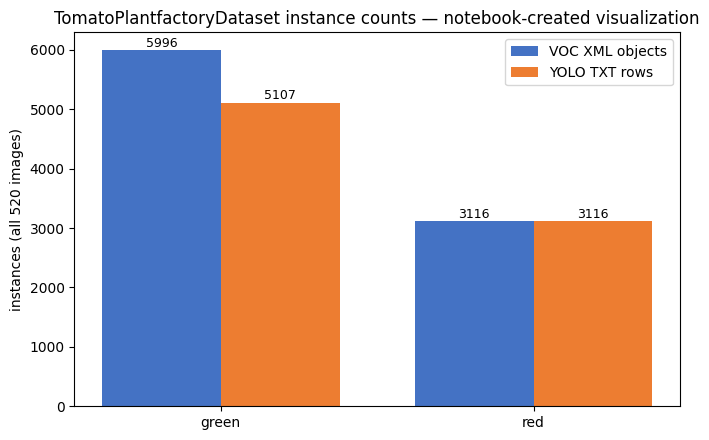

difficult excluded from YOLO: green 889, red 0


In [ ]:
import numpy as np

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(2)
width = 0.38
voc_series = [voc_counts["green"], voc_counts["red"]]
yolo_series = [yolo_counts["green"], yolo_counts["red"]]
ax.bar(x - width / 2, voc_series, width, label="VOC XML objects", color="#4472c4")
ax.bar(x + width / 2, yolo_series, width, label="YOLO TXT rows", color="#ed7d31")
for xi, v in zip(x - width / 2, voc_series):
    ax.text(xi, v + 60, str(v), ha="center", fontsize=9)
for xi, v in zip(x + width / 2, yolo_series):
    ax.text(xi, v + 60, str(v), ha="center", fontsize=9)
ax.set_xticks(x, ["green", "red"])
ax.set_ylabel("instances (all 520 images)")
ax.set_title("TomatoPlantfactoryDataset instance counts — notebook-created visualization")
ax.legend()
plt.tight_layout()
plt.show()
print(f"difficult excluded from YOLO: green {voc_difficult['green']}, red {voc_difficult['red']}")

### What this cell does / このセルの内容

Plots VOC vs YOLO instance counts per class from the actual recount, and prints the `difficult` breakdown that explains the 889-row difference.

*日本語:* 再計数結果からクラス別のVOC/YOLO件数を棒グラフにし、difficultの内訳(889行差の説明)を表示します。

## Verification 3 — VOC ↔ YOLO numeric agreement on the samples

For the three deterministic samples, each non-difficult VOC box is converted to normalized YOLO `(class, xc, yc, w, h)` and compared with the corresponding TXT row **in document order**. This checks both the coordinate math and the row ordering assumed by YOLO users.

*Japanese:* 3つのサンプルについて、VOCの非difficultボックスを正規化YOLO形式に変換し、TXTの各行(文書順)と数値比較します。

In [ ]:
tolerance = 1e-3  # normalized units; YOLO rows are written with ~6 decimals
CLASS_TO_ID = {"green": 0, "red": 1}
max_deviation = 0.0
for path in sample_paths:
    xml_path = DATASET_ROOT / "Annotations" / f"{path.stem}.xml"
    xml_w, xml_h, objects = parse_voc(xml_path)
    non_difficult = [o for o in objects if not o["difficult"]]
    lines = (DATASET_ROOT / "labels" / f"{path.stem}.txt").read_text().splitlines()
    rows = [line.split() for line in lines if line.strip()]
    assert len(rows) == len(non_difficult), f"row count mismatch in {path.name}"
    for row, obj in zip(rows, non_difficult):
        xc = (obj["xmin"] + obj["xmax"]) / 2 / xml_w
        yc = (obj["ymin"] + obj["ymax"]) / 2 / xml_h
        w = (obj["xmax"] - obj["xmin"]) / xml_w
        h = (obj["ymax"] - obj["ymin"]) / xml_h
        deviation = max(abs(float(row[1]) - xc), abs(float(row[2]) - yc),
                        abs(float(row[3]) - w), abs(float(row[4]) - h))
        max_deviation = max(max_deviation, deviation)
        assert int(row[0]) == CLASS_TO_ID[obj["name"]], f"class id mismatch in {path.name}"
print(f"max |VOC-converted - YOLO row| over 3 samples: {max_deviation:.2e} (tolerance {tolerance:.0e})")
assert max_deviation < tolerance, "VOC and YOLO annotations disagree beyond tolerance"
print("VOC and YOLO annotations agree on the deterministic samples")

max |VOC-converted - YOLO row| over 3 samples: 3.33e-07 (tolerance 1e-03)
VOC and YOLO annotations agree on the deterministic samples


### What this cell does / このセルの内容

Converts the samples' VOC boxes to normalized YOLO coordinates and compares row-by-row with the TXT labels, asserting class IDs and a maximum deviation below `1e-3` normalized units (actual deviation is printed).

*日本語:* サンプルのVOCボックスを正規化YOLO座標に変換し、TXT各行とクラスID・座標を比較します(許容差1e-3、実測の最大偏差を表示)。

## Verification 4 — the authors' reproducible YOLO split

`prepare_yolo_split.py` is run verbatim with the quick-start parameters `--train 0.8 --val 0.1 --seed 42` (default symlink mode, so the archive is not duplicated). Expected split sizes: **416 train / 52 val / 52 test** images.

*Japanese:* 著者の分割スクリプトをクイックスタートのパラメータ(0.8/0.1、seed 42、シンボリックリンク既定)でそのまま実行します。期待分割数は416/52/52です。

In [ ]:
urllib.request.urlretrieve(f"{RAW_BASE}/prepare_yolo_split.py", "/content/prepare_yolo_split.py")
assert Path("/content/prepare_yolo_split.py").stat().st_size == 4728, "prepare_yolo_split.py size mismatch"
print("fetched author prepare_yolo_split.py from pinned commit", AUTHOR_COMMIT)

result = subprocess.run(
    [sys.executable, "/content/prepare_yolo_split.py",
     "--root", str(DATASET_ROOT), "--out", "/content/yolo_dataset",
     "--train", "0.8", "--val", "0.1", "--seed", "42"],
    capture_output=True, text=True, timeout=1800,
)
print(result.stdout)
if result.stderr.strip():
    print("stderr:", result.stderr[:500])
assert result.returncode == 0, "prepare_yolo_split.py failed (see output above)"

print("\n--- generated data.yaml ---")
print(Path("/content/yolo_dataset/data.yaml").read_text())
for split in ("train", "val", "test"):
    n_images = len(list(Path(f"/content/yolo_dataset/images/{split}").glob("*")))
    n_labels = len(list(Path(f"/content/yolo_dataset/labels/{split}").glob("*")))
    print(f"{split}: {n_images} images, {n_labels} labels")
with open("/content/yolo_dataset/split_manifest.csv") as fh:
    print("\nsplit_manifest.csv first rows:")
    for _ in range(4):
        print(" ", next(fh).strip())

fetched author prepare_yolo_split.py from pinned commit 596c75e04ea08f8fec36c8104106cd92e1ebb132


Wrote split to /content/yolo_dataset
  train: 416 images
  val: 52 images
  test: 52 images
Data config: /content/yolo_dataset/data.yaml


--- generated data.yaml ---
path: /content/yolo_dataset
train: images/train
val: images/val
test: images/test

names:
  0: green
  1: red

train: 416 images, 416 labels
val: 52 images, 52 labels
test: 52 images, 52 labels

split_manifest.csv first rows:
  split,image
  train,0226.JPG
  train,0031.JPG
  train,0180.JPG


### What this cell does / このセルの内容

Fetches `prepare_yolo_split.py` from the pinned commit (size-checked) and runs it with the documented parameters, then prints the generated `data.yaml`, per-split image/label counts, and the first manifest rows.

*日本語:* 分割スクリプトを取得・実行し、生成された`data.yaml`、各分割の画像/ラベル数、マニフェスト先頭行を表示します。

## Results export

A small CSV with the measured verification numbers is written to `/content/outputs/annotation_summary.csv` (downloadable from the Colab file browser).

*Japanese:* 検証結果の要約CSVを`/content/outputs/annotation_summary.csv`に書き出します(Colabのファイルブラウザからダウンロード可能)。

In [ ]:
import csv

summary_rows = [
    ("images", expected["images"], paper_claims["images"]),
    ("voc_objects_total", expected["voc objects (total)"], paper_claims["voc objects (total)"]),
    ("voc_green", expected["voc green"], paper_claims["voc green"]),
    ("voc_red", expected["voc red"], paper_claims["voc red"]),
    ("voc_difficult_total", expected["voc difficult (total)"], paper_claims["voc difficult (total)"]),
    ("yolo_rows_total", expected["yolo rows (total)"], paper_claims["yolo rows (total)"]),
    ("split_train/val/test", "416/52/52", "416/52/52 (0.8/0.1, seed 42)"),
]
export_path = "/content/outputs/annotation_summary.csv"
Path("/content/outputs").mkdir(parents=True, exist_ok=True)
with open(export_path, "w", newline="") as fh:
    writer = csv.writer(fh)
    writer.writerow(["metric", "measured", "paper_claim"])
    writer.writerows(summary_rows)
print(f"wrote {export_path}")
pd.read_csv(export_path)

wrote /content/outputs/annotation_summary.csv


,metric,measured,paper_claim
0,images,520,520
1,voc_objects_total,9112,9112
2,voc_green,5996,5996
3,voc_red,3116,3116
4,voc_difficult_total,889,889
5,yolo_rows_total,8223,8223
6,split_train/val/test,416/52/52,"416/52/52 (0.8/0.1, seed 42)"


### What this cell does / このセルの内容

Writes the measured-vs-claimed summary table to CSV and displays it back.

*日本語:* 実測値と論文記載値の要約をCSVに保存して表示します。

## Interpretation, limitations, and validation record

**What was verified (dataset paper scope).** The official Mendeley **version 1** archive cited by the paper was downloaded inside Colab, matched its recorded SHA-256 (`e6bcaf…05faf`) and size (3,402,876,899 bytes), extracted to the documented `Images/` / `Annotations/` / `labels/` layout, and every published count was reproduced: 520 images, 9112 VOC objects (5996 green + 3116 red), 8223 YOLO rows, with the 889-object difference explained by `difficult`-marked green fruits; VOC and YOLO annotations agree numerically on the deterministic samples; the authors' scripts ran unchanged and produced the documented 416/52/52 split.

**Limitations.**
- This verifies the **dataset**, not a detector: no model was trained or evaluated because the paper releases no weights and no SM-YOLOv5 implementation exists publicly (it belongs to the companion Sensors 2023 paper).
- A dataset-level count reproduction does not measure detection accuracy; the paper itself reports no benchmark numbers.
- Download time dominates the runtime and varies with network conditions; the archive is a single 3.4 GB file so no smaller official subset exists.
- The GitHub quick-start repository postdates the paper (May 2026); it was used only as documented tooling for this dataset, from a pinned commit.
- Mendeley also hosts later dataset versions (v2 2023-06-08, v3 2026-05-21); this notebook pins **v1**, the version cited by the article.

**License / attribution.** Dataset distributed under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/) (Mendeley record). If you use the data, cite: Wu, Z.-W., Liu, M.-H., Sun, C.-X. & Wang, X.-F. (2023), *Data in Brief* 48, 109291, doi:10.1016/j.dib.2023.109291, and the dataset DOI 10.17632/8h3s6jkyff.1.

**References.**
1. Wu et al., Data in Brief 48, 109291 (2023). https://doi.org/10.1016/j.dib.2023.109291 — PMC10294037
2. TomatoPlantfactoryDataset, Mendeley Data, https://data.mendeley.com/datasets/8h3s6jkyff/1
3. Author quick-start repository, https://github.com/veveup/Tomato-Plant-Factory-Dataset @ `596c75e04ea08f8fec36c8104106cd92e1ebb132`
4. Wang X. et al., Lightweight SM-YOLOv5 tomato fruit detection algorithm for plant factory, Sensors 23, 3336 (2023). https://doi.org/10.3390/s23063336

**Validation record.** Executed end-to-end on a fresh Colab CPU runtime on 2026-10-08 (see the repository publication record for measured timings and the archived executed output).

*Japanese:* 本ノートブックはデータセット論文の公開値(520画像・9112個体・5996/3116・YOLO 8223行・difficult 889)をMendeley v1アーカイブ全体の再計数により再現しました。検出モデルの学習・評価は行っていません(重み・実装が未公開のため)。ライセンスはCC BY 4.0で、利用時は原論文とデータセットDOIの引用が必要です。